In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
dataset_path = r"C:\Users\Umair Ali\Downloads\Project\plant-diseases-detection\new_plant_diseases_dataset"

train_dir = dataset_path + "/train"
valid_dir = dataset_path + "/valid"

Number of Classes: 38
Sample Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']

Sample Class Counts:
Apple___Apple_scab → 2016
Apple___Black_rot → 1987
Apple___Cedar_apple_rust → 1760
Apple___healthy → 2008
Blueberry___healthy → 1816


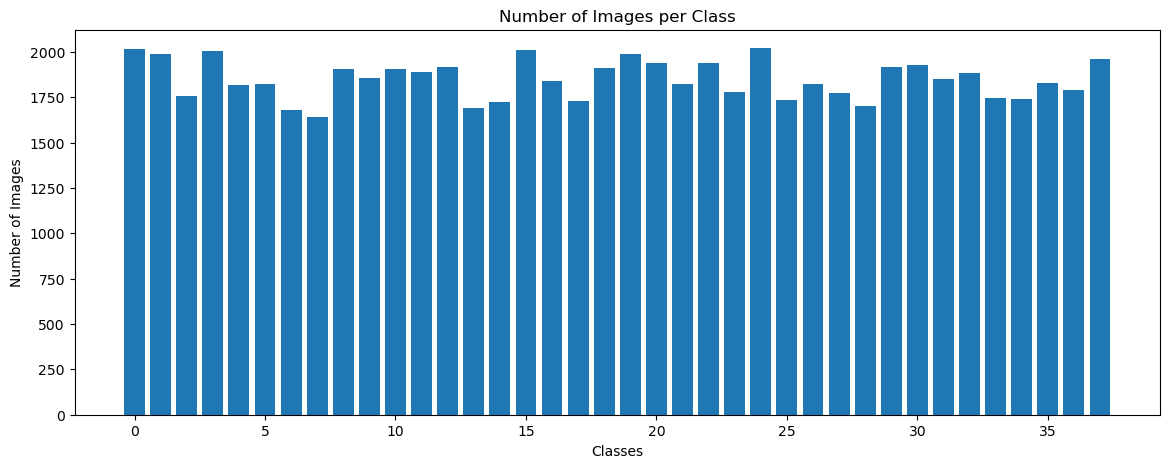

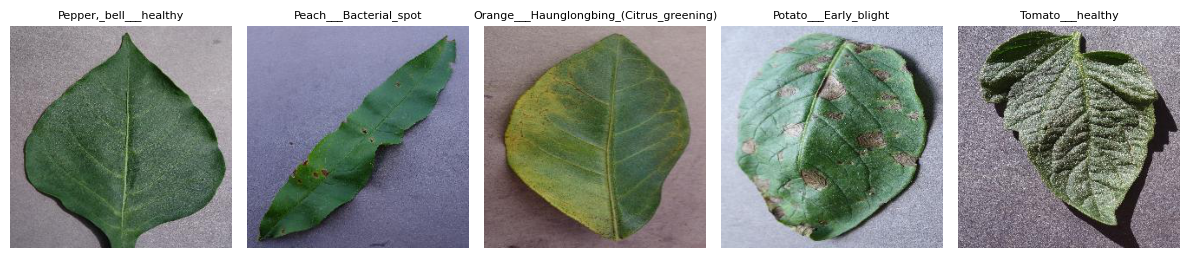

In [7]:
import os
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

# =====================
# 1) Load Classes 
# =====================
classes = [c for c in os.listdir(train_dir) 
           if os.path.isdir(os.path.join(train_dir, c))]

print("Number of Classes:", len(classes))
print("Sample Classes:", classes[:10])


# =====================
# 2) Count Images per Class
# =====================
class_counts = {}

for c in classes:
    class_path = os.path.join(train_dir, c)
    class_counts[c] = len(os.listdir(class_path))


print("\nSample Class Counts:")
for k in list(class_counts.keys())[:5]:
    print(k, "→", class_counts[k])


# =====================
# 3) Plot Distribution
# =====================
plt.figure(figsize=(14,5))
plt.bar(range(len(classes)), list(class_counts.values()))
plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()


# =====================
# 4) Show Sample Images
# =====================
plt.figure(figsize=(12,6))

for i in range(5):
    class_name = random.choice(classes)
    class_path = os.path.join(train_dir, class_name)
    
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    img = image.load_img(img_path)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

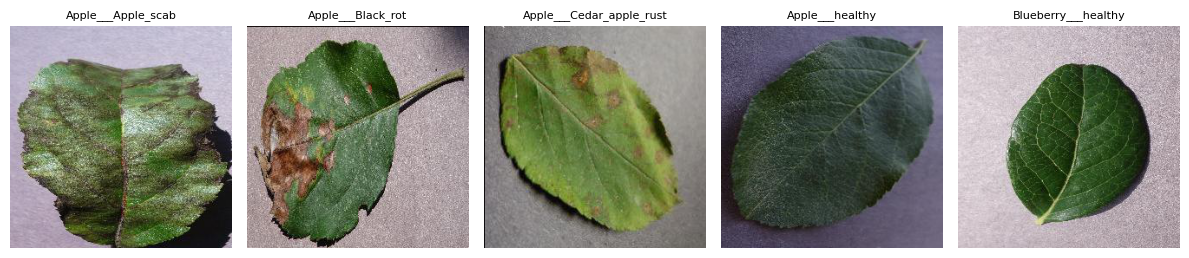

In [8]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image
import os

classes = os.listdir(train_dir)

plt.figure(figsize=(12,5))

for i in range(5):
    
    class_name = classes[i]
    
    class_path = os.path.join(train_dir, class_name)
    
    img_name = random.choice(os.listdir(class_path)) 
    
    img_path = os.path.join(class_path, img_name)
    
    img = image.load_img(img_path)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


In [10]:
def extract_features(folder, max_per_class=100):  # per class, not total
    X = []
    y = []

    for label in os.listdir(folder):
        class_path = os.path.join(folder, label)

        if not os.path.isdir(class_path):
            continue

        count = 0  # reset per class
        for img_name in os.listdir(class_path):

            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)

            try:
                img = image.load_img(img_path, target_size=(224,224))
                img = image.img_to_array(img)
                img = np.expand_dims(img, axis=0)
                img = preprocess_input(img)

                feat = model.predict(img, verbose=0)

                X.append(feat.flatten())
                y.append(label)
                count += 1

            except:
                continue

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = extract_features(train_dir, max_per_class=100)
X_valid, y_valid = extract_features(valid_dir, max_per_class=30)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)

In [ ]:
import pandas as pd

df_train = pd.DataFrame(X_train_pca)

In [ ]:
df_train.info()

In [ ]:
plt.imshow(X_train_pca[:5], aspect='auto')
plt.colorbar()
plt.title("Feature Visualization")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_train_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=y_train_enc)
plt.title("2D Visualization")
plt.show()

In [ ]:
# ============================================================
#  EfficientNetV2B0 
# ============================================================

import os, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint




In [ ]:
# ============================================================
# 1. CONFIG
# ============================================================

IMG_SIZE = 224
BATCH = 64
SEED = 42

# ============================================================
# 2. LOAD DATA
# ============================================================
class_names = sorted([
    c for c in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, c))
])

NUM_CLASSES = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

paths, labels = [], []

for cls in class_names:
    folder = os.path.join(train_dir, cls)
    for img in os.listdir(folder):
        paths.append(os.path.join(folder, img))
        labels.append(class_to_idx[cls])

paths = np.array(paths)
labels = np.array(labels)

print("Total images:", len(paths))
print("Classes:", NUM_CLASSES)


In [ ]:
# ============================================================
# 3. STRATIFIED SPLIT (70 / 15 / 15)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(len(X_train), len(X_val), len(X_test))

# ============================================================
# 4. DATA PIPELINE + AUGMENTATION
# ============================================================
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, tf.one_hot(label, NUM_CLASSES)

def load_train(path, label):
    img, label = load_image(path, label)
    img = aug(img, training=True)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(2000).map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)



In [ ]:
# ============================================================
# 5. MODEL
# ============================================================
MODEL_PATH = "/kaggle/working/best_model.keras"

if os.path.exists(MODEL_PATH):
    print("Loading saved model...")
    model = tf.keras.models.load_model(MODEL_PATH)

else:
    base = EfficientNetV2B0(include_top=False, weights="imagenet")
    base.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs)

# ============================================================
# 6. LOSS + OPTIMIZER (IMPORTANT FOR PAPER)
# ============================================================

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

steps_per_epoch = len(X_train) // BATCH

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * 20
)
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

In [ ]:
# ============================================================
# 7. TRAIN PHASE 1
# ============================================================



callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

In [ ]:
# ============================================================
# 8. FINE TUNING
# ============================================================
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

In [ ]:
# ============================================================
# 9. EVALUATION FUNCTION
# ============================================================
def evaluate(ds):
    y_true = []
    y_pred = []

    for x, y in ds:
        preds = model.predict(x, verbose=0)

        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")

    print("\nAccuracy:", acc)
    print("F1 Macro:", f1_macro)
    print("F1 Weighted:", f1_weighted)
    print("Precision:", precision)
    print("Recall:", recall)

    return y_true, y_pred

In [ ]:
# ============================================================
# 10. VALIDATION + TEST
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


val_true, val_pred   = evaluate(val_ds)
test_true, test_pred = evaluate(test_ds)

print("\nClassification Report:\n")
print(classification_report(test_true, test_pred, target_names=class_names))

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(test_true, test_pred)
cm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()

# ============================================================
# 12. PER CLASS ACCURACY
# ============================================================
cm_raw = confusion_matrix(test_true, test_pred)
per_class = cm_raw.diagonal() / cm_raw.sum(axis=1)

for i, acc in enumerate(per_class):
    print(class_names[i], ":", round(acc, 4))

In [ ]:
# ============================================================
# 13. OVERFITTING GAP
# ============================================================
train_acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc   = history1.history["val_accuracy"] + history2.history["val_accuracy"]

gap = abs(train_acc[-1] - val_acc[-1])
print("Overfitting Gap:", gap)
# ============================================================
# 14. SAVE
# ============================================================
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

model.save("/kaggle/working/final_model.keras")



Overfitting Gap: 2.6941299438476562e-05

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import json
import os

DATASET_PATH = "/kaggle/input/datasets/ayamahmoudalhareidi/dmprojectds"


model = load_model(f"{DATASET_PATH}/final_model.keras")


with open(f"{DATASET_PATH}/class_names.json", "r") as f:
    class_names = json.load(f)


if isinstance(class_names, dict):
    class_names = list(class_names.values())

print(" Model Loaded")
print(" Number of Classes:", len(class_names))



In [ ]:

img_path6="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/AppleScab1.JPG"
img_path7="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/AppleCedarRust2.JPG"
img_path8="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoEarlyBlight3.JPG"
img_path9="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus3.JPG"
img_path0="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy2.JPG"

def predict_image(img_path):
    print("Running prediction...")

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    pred = model.predict(img_array)
    class_index = np.argmax(pred)

    print("Predicted Class:", class_names[class_index])
    print("Confidence:", float(np.max(pred)))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

predict_image(img_path6)
predict_image(img_path7)
predict_image(img_path8)
predict_image(img_path9)
predict_image(img_path0)

**Machine Learning Models**


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lr  = LogisticRegression(max_iter=3000, solver='saga', C=10, n_jobs=-1)
lr.fit(X_train_pca, y_train_enc)

svm = SVC(kernel='rbf', C=100, gamma='scale', probability=True)
svm.fit(X_train_pca, y_train_enc)

rf  = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train_enc)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train_enc)

print("Done ")

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[('lr', lr), ('svm', svm), ('rf', rf)],
    voting='soft'
)
ensemble.fit(X_train_pca, y_train_enc)
print("Ensemble Done ")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf,
    "KNN": knn,
    "Ensemble": ensemble
}

for name, m in models.items():
    pred = m.predict(X_valid_pca)
    print(f"\n{name}:")
    print(f"  Accuracy  : {round(accuracy_score(y_valid_enc, pred), 4)}")
    print(f"  F1        : {round(f1_score(y_valid_enc, pred, average='weighted'), 4)}")
    print(f"  Precision : {round(precision_score(y_valid_enc, pred, average='weighted'), 4)}")
    print(f"  Recall    : {round(recall_score(y_valid_enc, pred, average='weighted'), 4)}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = ["Accuracy", "F1", "Precision", "Recall"]
metrics_data = {}

for name, m in models.items():
    pred = m.predict(X_valid_pca)
    metrics_data[name] = [
        accuracy_score(y_valid_enc, pred),
        f1_score(y_valid_enc, pred, average="weighted"),
        precision_score(y_valid_enc, pred, average="weighted"),
        recall_score(y_valid_enc, pred, average="weighted")
    ]

x = np.arange(len(metric_names))
width = 0.15

plt.figure(figsize=(14, 6))
for i, name in enumerate(models.keys()):
    plt.bar(x + i * width, metrics_data[name], width=width, label=name)

plt.xticks(x + width * 2, metric_names)
plt.ylim(0, 1.1)
plt.title("Model Comparison including Ensemble")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess


model_resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')

external_images = [
    "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/CornCommonRust1.JPG",
    "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy2.JPG",
    "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus2.JPG",
]

plt.figure(figsize=(15, 5))

for i, img_path in enumerate(external_images):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)  

    feat = model_resnet.predict(img_array, verbose=0).flatten() 
    feat_scaled = scaler.transform([feat])
    feat_pca = pca.transform(feat_scaled)

    pred_label = ensemble.predict(feat_pca)[0]
    pred_name  = le.inverse_transform([pred_label])[0]

    plt.subplot(1, len(external_images), i + 1)
    plt.imshow(image.load_img(img_path))
    plt.title(f"Pred: {pred_name[:20]}", fontsize=8)
    plt.axis("off")

plt.suptitle("External Images - Ensemble Prediction", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open("/kaggle/working/ensemble.pkl", "wb") as f:

    pickle.dump({
        "ensemble": ensemble,
        "scaler": scaler,
        "pca": pca,
        "le": le
    }, f)

print("Ensemble saved successfully ")

In [ ]:
import os
print(os.listdir('/kaggle/working'))

In [ ]:
# =========================================================
# INSTALL
# =========================================================

!pip install gradio -q

# =========================================================
# IMPORTS
# =========================================================

import os
import json
import pickle

import gradio as gr
import numpy as np
import tensorflow as tf

from PIL import Image

from tensorflow.keras.preprocessing import image as keras_image

from tensorflow.keras.applications.efficientnet_v2 import (
    preprocess_input as eff_preprocess
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

# =========================================================
# SETTINGS
# =========================================================

IMG_SIZE = 224

# مودل الصور
BASE_DIR = "/kaggle/input/datasets/ayamahmoudalhareidi/dmprojectds"

# الانسمبل
ENSEMBLE_PATH = "/kaggle/working/ensemble.pkl"

# =========================================================
# LOAD MODELS
# =========================================================

print("Loading EfficientNetV2B0 model...")

deep_model = tf.keras.models.load_model(
    os.path.join(BASE_DIR, "final_model.keras")
)

print("Loading ResNet50 feature extractor...")

feature_extractor = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("Loading class names...")

with open(os.path.join(BASE_DIR, "class_names.json"), "r") as f:
    class_names = json.load(f)

if isinstance(class_names, dict):
    class_names = list(class_names.values())

print("Loading Ensemble model...")

with open(ENSEMBLE_PATH, "rb") as f:

    bundle = pickle.load(f)

    ensemble = bundle["ensemble"]
    scaler   = bundle["scaler"]
    pca      = bundle["pca"]
    le       = bundle["le"]

print("Everything Loaded Successfully ✅")

# =========================================================
# HELPERS
# =========================================================

def parse_class(raw_name):

    parts = raw_name.split("___")

    plant = parts[0].replace("_", " ").strip()

    disease = (
        parts[1].replace("_", " ").strip()
        if len(parts) > 1
        else "Unknown"
    )

    return plant, disease


def prepare_image(pil_img, preprocess_function):

    img = pil_img.convert("RGB")

    img = img.resize((IMG_SIZE, IMG_SIZE))

    arr = keras_image.img_to_array(img)

    arr = np.expand_dims(arr, axis=0)

    arr = preprocess_function(arr)

    return arr

# =========================================================
# MAIN PREDICTION FUNCTION
# =========================================================

def predict_disease(pil_img):

    if pil_img is None:
        return "Please upload an image.", {}

    # =====================================================
    # EfficientNet Prediction
    # =====================================================

    eff_input = prepare_image(
        pil_img,
        eff_preprocess
    )

    eff_probs = deep_model.predict(
        eff_input,
        verbose=0
    )[0]

    # =====================================================
    # ResNet50 Feature Extraction
    # =====================================================

    res_input = prepare_image(
        pil_img,
        resnet_preprocess
    )

    features = feature_extractor.predict(
        res_input,
        verbose=0
    ).flatten()

    # =====================================================
    # PCA + Scaling
    # =====================================================

    features_scaled = scaler.transform([features])

    features_pca = pca.transform(features_scaled)

    # =====================================================
    # Ensemble Prediction
    # =====================================================

    ensemble_probs = ensemble.predict_proba(
        features_pca
    )[0]

    # =====================================================
    # FUSION / VOTING
    # =====================================================

    final_probs = (
        0.6 * eff_probs
        +
        0.4 * ensemble_probs
    )

    # =====================================================
    # FINAL RESULT
    # =====================================================

    best_idx = np.argmax(final_probs)

    final_class = class_names[best_idx]

    confidence = float(final_probs[best_idx]) * 100

    plant, disease = parse_class(final_class)

    healthy = "healthy" in disease.lower()

    # =====================================================
    # TOP 5 RESULTS
    # =====================================================

    top5_idx = np.argsort(final_probs)[::-1][:5]

    top5 = {}

    for idx in top5_idx:

        _, d = parse_class(class_names[idx])

        top5[d] = float(final_probs[idx])

    # =====================================================
    # INDIVIDUAL MODEL RESULTS
    # =====================================================

    eff_idx = np.argmax(eff_probs)

    eff_class = class_names[eff_idx]

    _, eff_dis = parse_class(eff_class)

    eff_conf = float(np.max(eff_probs)) * 100

    ens_idx = np.argmax(ensemble_probs)

    ens_class = le.inverse_transform([ens_idx])[0]

    _, ens_dis = parse_class(ens_class)

    ens_conf = float(np.max(ensemble_probs)) * 100

    # =====================================================
    # STATUS
    # =====================================================

    status = "Healthy 🌿" if healthy else "Diseased 🔴"

    # =====================================================
    # RESULT TEXT
    # =====================================================

    result = f"""
🌱 Plant:
{plant}

🦠 Disease:
{disease}

📌 Status:
{status}

🎯 Final Confidence:
{confidence:.2f}%

━━━━━━━━━━━━━━━━━━━━━━

🧠 EfficientNetV2B0

Prediction:
{eff_dis}

Confidence:
{eff_conf:.2f}%

━━━━━━━━━━━━━━━━━━━━━━

🤖 Ensemble Model

Prediction:
{ens_dis}

Confidence:
{ens_conf:.2f}%

━━━━━━━━━━━━━━━━━━━━━━

✅ Final Decision:
Fusion Voting Between
Deep Learning + Ensemble Learning
"""

    return result, top5

# =========================================================
# PROFESSIONAL CSS
# =========================================================

custom_css = """

body {
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
}

.gradio-container {
    font-family: 'Segoe UI', sans-serif !important;
    max-width: 1400px !important;
    margin: auto !important;
}

/* MAIN TITLE */

.main-title {
    text-align: center;
    font-size: 42px;
    font-weight: bold;
    color: white;
    margin-bottom: 10px;
}

.sub-title {
    text-align: center;
    color: #dfe6e9;
    font-size: 18px;
    margin-bottom: 35px;
}

/* BUTTON */

button {
    background: linear-gradient(90deg, #00c853, #64dd17) !important;
    border: none !important;
    border-radius: 15px !important;
    font-size: 18px !important;
    font-weight: bold !important;
    color: white !important;
    height: 55px !important;
    transition: 0.3s !important;
}

button:hover {
    transform: scale(1.03);
    box-shadow: 0px 0px 20px rgba(100,221,23,0.7);
}

/* TEXTBOX */

textarea {
    border-radius: 18px !important;
    background: rgba(255,255,255,0.08) !important;
    color: white !important;
    font-size: 16px !important;
}

/* IMAGE */

.upload-box {
    border-radius: 20px !important;
    overflow: hidden;
}

/* FOOTER */

footer {
    visibility: hidden;
}
"""

# =========================================================
# GUI
# =========================================================

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="green",
        secondary_hue="emerald"
    ),
    css=custom_css
) as demo:

    # =====================================================
    # HEADER
    # =====================================================

    gr.Markdown(
        """
<div class="main-title">
🌿 Plant Disease Detection System
</div>

<div class="sub-title">
AI-Powered Hybrid Classification using EfficientNetV2B0 + Ensemble Learning
</div>
"""
    )

    # =====================================================
    # MAIN SECTION
    # =====================================================

    with gr.Row():

        # =================================================
        # LEFT SIDE
        # =================================================

        with gr.Column(scale=1):

            gr.Markdown("## 📤 Upload Plant Leaf")

            image_input = gr.Image(
                type="pil",
                label="Upload Image",
                elem_classes="upload-box"
            )

            gr.Markdown(
                """
### 🤖 AI Models Used

- EfficientNetV2B0
- ResNet50 Feature Extraction
- SVM
- Random Forest
- Logistic Regression
- Fusion Voting
"""
            )

            predict_btn = gr.Button(
                "🔍 Analyse Plant Disease",
                variant="primary"
            )

        # =================================================
        # RIGHT SIDE
        # =================================================

        with gr.Column(scale=2):

            gr.Markdown("## 📋 Prediction Analysis")

            result_output = gr.Textbox(
                label="Final Result",
                lines=22
            )

            confidence_output = gr.Label(
                num_top_classes=5,
                label="📊 Top Predictions Confidence"
            )

    # =====================================================
    # EXAMPLES
    # =====================================================

    gr.Markdown("## 🌱 Quick Test Examples")

    gr.Examples(
        examples=[
            ["/kaggle/input/vipoooool/new-plant-diseases-dataset/test/test/TomatoEarlyBlight3.JPG"],
            ["/kaggle/input/vipoooool/new-plant-diseases-dataset/test/test/AppleScab1.JPG"],
            ["/kaggle/input/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy2.JPG"],
        ],
        inputs=image_input
    )

    # =====================================================
    # BUTTON ACTION
    # =====================================================

    predict_btn.click(
        fn=predict_disease,
        inputs=image_input,
        outputs=[
            result_output,
            confidence_output
        ]
    )

# =========================================================
# LAUNCH
# =========================================================

import warnings
warnings.filterwarnings("ignore")

demo.launch(share=True)